In [1]:
import brian2
from brian2 import ms, mV, nF, nS

In [2]:
neuron_model = """
    dv/dt = (-g_m*(v - V_res) + I_syn)/C_m : volt
    I_syn = I_AMPA + I_NMDA + I_GABA : ampere
    I_AMPA = -scl_AMPA*g_AMPA*(v - V_E) : ampere
    g_AMPA = (g_AMPA_d - g_AMPA_r)/norm_AMPA : siemens
    dg_AMPA_r/dt = -g_AMPA_r/tau_AMPA_r : siemens
    dg_AMPA_d/dt = -g_AMPA_d/tau_AMPA_d : siemens
    I_NMDA = 0*mA : ampere
    I_GABA = 0*mA : ampere
"""
PCs = brian2.NeuronGroup(
    80, neuron_model,
    threshold='v > -52*mV',
    reset='v = -55*mV',
    namespace=dict(
        V_res = -70*mV,
        V_E = 0.*mV,
        V_I = -70*mV,
        g_m = 25*nS,
        C_m = 0.5*nF,#tau_m = C_m/g_m
        tau_AMPA_r = 0.5*ms,
        tau_AMPA_d = 2.*ms,
        scl_AMPA = 1.,
        norm_AMPA = 0.472689
    )
)

In [7]:
S = brian2.Synapses(
    PCs, PCs,
    on_pre="""
    g_AMPA_r += w
    g_AMPA_d += w
    """,
    namespace=dict(
        w = 825*nS
    )
)
S.connect(p=0.1)

In [8]:
monitor = brian2.SpikeMonitor(PCs)
net = brian2.Network()
net.add([PCs, S, monitor])

In [9]:
net.run(100*ms)

INFO       No numerical integration method specified for group 'neurongroup', using method 'euler' (took 0.03s, trying other methods took 0.11s). [brian2.stateupdaters.base.method_choice]


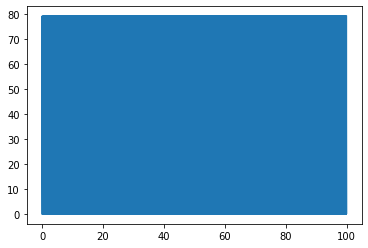

In [14]:
import matplotlib.pyplot as plt
plt.plot(monitor.t/ms, monitor.i, markersize=1)